In [1]:
import landon_scripts.data_funcs_old as data_funcs_old
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shelve

In [15]:
# read in saved qn drug data variables
qn_drug_lv3data = shelve.open("../data/expression/drug_data/qn_drug_lv3data") 
qndrug_target_vec = qn_drug_lv3data['qndrug_target_vec']
drug_data_qn = qn_drug_lv3data['drug_data_qn']
drug_data_qn

'drug_data_qn'

In [2]:
drug_data, landmark_genes = data_funcs_old.read_drug_data()
dis_data = data_funcs_old.read_dis_data(landmark_genes)

prop of na: 0.00571


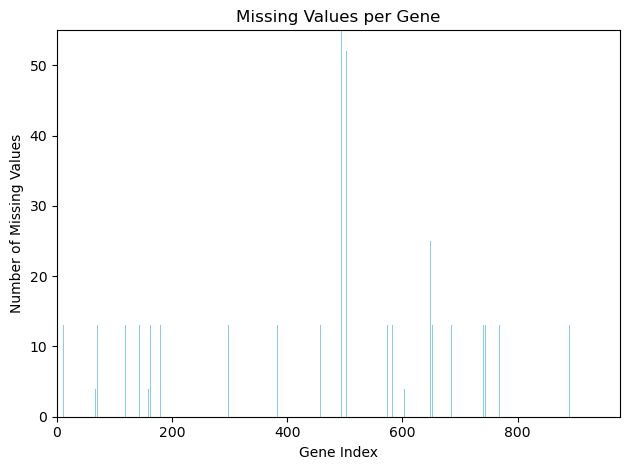

In [50]:
# NA investigation
# 978 genes in the landmark genes
# 219 disease samples

# count number of NA in each disease data row
dis_data_na_count = dis_data.isna().sum(axis=1)
print('prop of na:', np.round(dis_data_na_count.sum()/(978*219), 5))

# Plot the missing values for each gene
plt.bar(range(len(dis_data_na_count)), dis_data_na_count.values, color='skyblue')
plt.xlabel('Gene Index')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Gene')
plt.xlim([0, 978])
plt.ylim([0,55])
plt.tight_layout()
plt.show()

prop of na: 0.01422


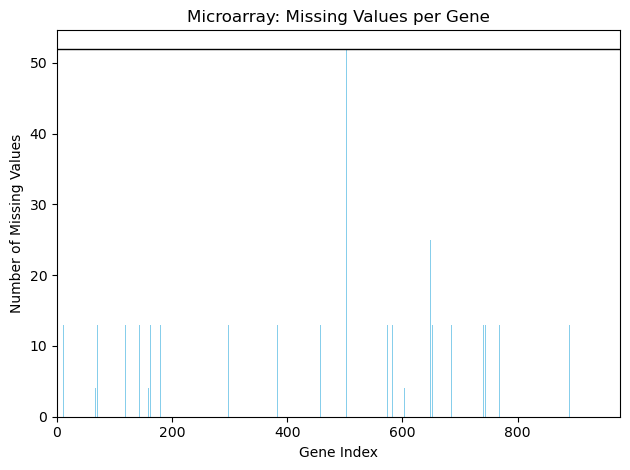

In [46]:
ma_samples = []
for disease_sample in dis_data.columns:
    if data_funcs_old.get_dis_meta(disease_sample, 'type') == 'microarray':
        ma_samples.append(disease_sample)
ma_data = dis_data[ma_samples]

# 52 disease samples

# count number of NA in each disease data row
ma_data_na_count = ma_data.isna().sum(axis=1)
print('prop of na:', np.round(ma_data_na_count.sum()/(978*52), 5))

# Plot the missing values for each gene
plt.bar(range(len(ma_data_na_count)), ma_data_na_count.values, color='skyblue')
plt.xlabel('Gene Index')
plt.ylabel('Number of Missing Values')
plt.title('Microarray: Missing Values per Gene')
plt.xlim([0, 978])
plt.tight_layout()
plt.axhline(y=52, color='black', linewidth=1)
plt.show()


prop of na: 0.00307


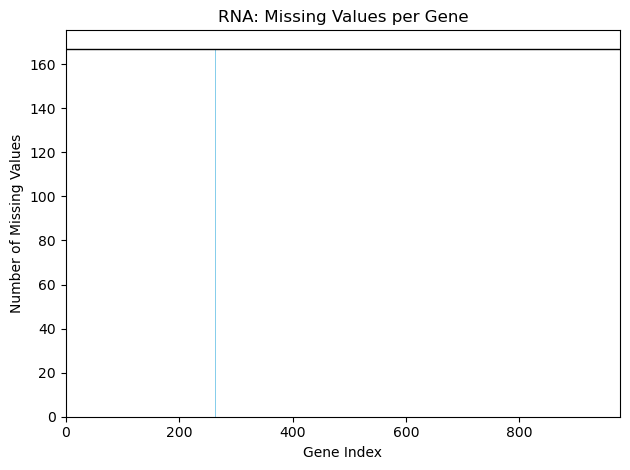

In [52]:
rna_samples = []
for disease_sample in dis_data.columns:
    if data_funcs_old.get_dis_meta(disease_sample, 'type') == 'rnaseq':
        rna_samples.append(disease_sample)
rna_data = dis_data[rna_samples]

# 167 disease samples

# count number of NA in each disease data row
rna_data_na_count = rna_data.isna().sum(axis=1)
print('prop of na:', np.round(rna_data_na_count.sum()/(978*167), 5))

# Plot the missing values for each gene
plt.bar(range(len(rna_data_na_count)), rna_data_na_count.values, color='skyblue')
plt.xlabel('Gene Index')
plt.ylabel('Number of Missing Values')
plt.title('RNA: Missing Values per Gene')
plt.xlim([0, 978])
plt.axhline(y=167, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [54]:
rna_data

Disease Samples,GSM1646957,GSM1646961,GSM1646975,GSM1646980,GSM1647012,GSM1647013,GSM1647024,GSM1647025,GSM1647037,GSM1647038,...,GSM3071041,GSM3071043,GSM3071045,GSM3071047,GSM3071049,GSM3071051,GSM3071053,GSM3071055,GSM3071057,GSM3071059
GeneID,,,,,,,,,,,,,,,,,,,,,
5720,3655.0,3883.0,2643.0,5939.0,3946.0,4030.0,4454.0,3611.0,3965.0,8974.0,...,3139.0,2522.0,2943.0,3851.0,5989.0,9935.0,5739.0,6592.0,6031.0,2558.0
466,469.0,264.0,43.0,308.0,278.0,186.0,547.0,178.0,705.0,482.0,...,75.0,129.0,172.0,201.0,1.0,602.0,134.0,334.0,470.0,161.0
6009,2440.0,1327.0,477.0,2058.0,1722.0,1337.0,2488.0,1165.0,4919.0,4911.0,...,407.0,399.0,198.0,1324.0,607.0,775.0,824.0,1056.0,440.0,1176.0
2309,468.0,384.0,307.0,1402.0,589.0,387.0,1403.0,521.0,1701.0,951.0,...,754.0,956.0,710.0,1257.0,1862.0,441.0,878.0,1418.0,34.0,932.0
387,18864.0,13572.0,8881.0,28555.0,25826.0,19150.0,40113.0,17866.0,30022.0,36181.0,...,8109.0,6683.0,5808.0,12342.0,8428.0,12527.0,6013.0,10328.0,9867.0,9269.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23200,672.0,320.0,151.0,791.0,696.0,352.0,1064.0,277.0,2501.0,1126.0,...,591.0,747.0,596.0,598.0,2215.0,26.0,1054.0,1636.0,310.0,374.0
51293,130.0,205.0,515.0,355.0,207.0,679.0,821.0,668.0,210.0,561.0,...,62.0,120.0,177.0,188.0,137.0,824.0,793.0,358.0,411.0,158.0
10962,68.0,41.0,3.0,42.0,59.0,34.0,59.0,22.0,50.0,94.0,...,0.0,57.0,42.0,20.0,3.0,1.0,0.0,73.0,0.0,23.0


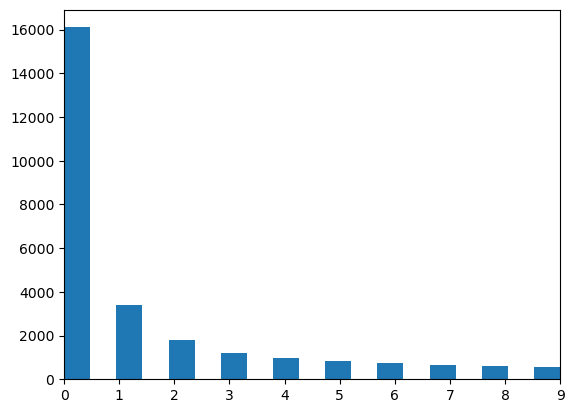

In [81]:
small = rna_data.values.flatten()
small = small[small<10]
plt.hist(small, bins=19)
plt.xlim([0, 9])
plt.show()

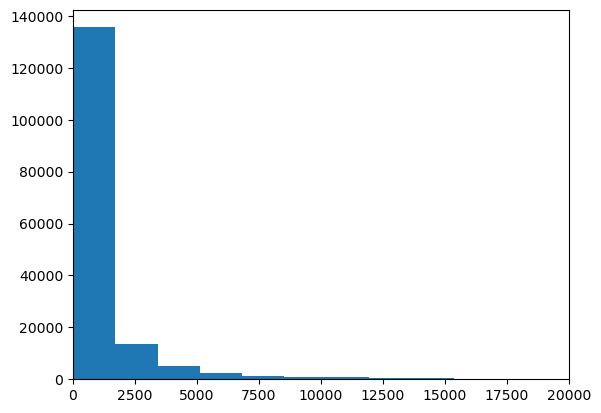

In [24]:
values = []
for disease_sample in dis_data.columns:
    if data_funcs_old.get_dis_meta(disease_sample, 'type') == 'rnaseq':
        values.extend(dis_data[disease_sample].values)
plt.hist(values, bins=1000)
plt.xlim([0, 20000])
plt.show()


In [126]:
# https://github.com/ShawnLYU/Quantile_Normalize
def quantile_normalize(df_input):
    df = df_input.copy()
    #compute rank
    dic = {}
    for col in df:
        dic.update({col : sorted(df[col])})
    sorted_df = pd.DataFrame(dic)
    rank = sorted_df.mean(axis = 1).tolist()
    #sort
    for col in df:
        t = np.searchsorted(np.sort(df[col]), df[col])
        df[col] = [rank[i] for i in t]
    return df

In [170]:
data = {
    'S1': [5, 2, 3, 4],
    'S2': [4, 1, 4, 2],
    'S3': [3, 4, 6, 8]
}
x = pd.DataFrame(data)
x.index = ['A', 'B', 'C', 'D']
x

,S1,S2,S3
A,5,4,3
B,2,1,4
C,3,4,6
D,4,2,8


In [171]:
quantile_normalize(x)

,S1,S2,S3
A,5.666667,4.666667,2.000000
B,2.000000,2.000000,3.000000
C,3.000000,4.666667,4.666667
D,4.666667,3.000000,5.666667


In [136]:
ma_samples = []
for disease_sample in dis_data.columns:
    if data_funcs_old.get_dis_meta(disease_sample, 'type') == 'microarray':
        ma_samples.append(disease_sample)
ma_data = dis_data[ma_samples]

# ma_data = ma_data.iloc[:,:4]
# ma_data.dropna(inplace=True)
# ma_data = np.log2(ma_data + 1)
ma_data

Disease Samples,GSM484450,GSM484453,GSM484454,GSM484457,GSM484462,GSM484477,GSM484479,GSM409137,GSM409138,GSM409139,...,GSM484369,GSM484370,GSM484371,GSM484372,GSM484373,GSM484374,GSM484375,GSM484377,GSM484378,GSM484379
GeneID,,,,,,,,,,,,,,,,,,,,,
5720,2.471917,2.533743,2.400866,2.381452,2.605398,2.541487,2.469798,-0.003972,12.492237,12.029694,...,2.427295,2.510762,2.230893,2.339730,2.440679,2.226160,2.239478,2.233720,2.357473,2.400148
466,-0.089527,-0.115732,-0.101819,-0.018170,-0.119542,-0.017855,-0.119616,2.507151,5.879857,4.681379,...,-0.015839,-0.186701,-0.033675,-0.030788,-0.010621,-0.093223,-0.081889,-0.102400,-0.039658,-0.071411
6009,2.795884,2.934972,2.715569,2.724173,2.900263,2.672966,2.882289,2.054041,2.573850,2.019334,...,2.814330,2.892419,2.822818,2.715261,2.820262,2.827360,2.929149,2.864576,2.671555,2.712769
2309,0.386953,0.401729,0.382215,0.358355,0.405478,0.416604,0.399945,2.553713,24.828009,21.781526,...,0.388284,0.314173,0.350951,0.368174,0.348411,0.422487,0.375252,0.368631,0.369105,0.385801
387,2.809470,2.938254,2.717415,2.726580,2.902211,2.831692,2.885613,2.320439,9.213339,9.518605,...,2.816931,2.897124,2.873904,2.717124,2.823444,2.830011,2.932543,2.868629,2.685413,2.715894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23200,-0.031962,-0.032757,-0.016701,-0.037461,-0.000073,-0.018842,-0.016641,1.695483,13.165315,10.398895,...,-0.032934,-0.094748,-0.083755,-0.050408,-0.029681,-0.012274,0.003039,-0.031765,-0.040208,-0.020644
51293,-0.080359,-0.084295,-0.095572,-0.098345,-0.100528,-0.104295,-0.087225,0.097122,0.111427,0.619225,...,-0.084137,0.045156,0.104215,-0.098860,-0.084205,-0.063165,-0.041316,-0.083557,-0.108537,-0.062210
10962,1.247066,1.312529,1.263275,1.225147,1.337165,1.359816,1.290781,11.378471,7.710375,6.381312,...,1.276199,1.295063,1.178623,1.190391,1.238874,1.241794,1.151568,1.123090,1.187795,1.310469


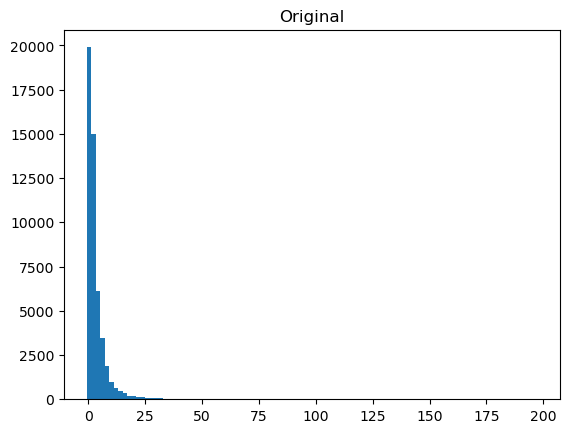

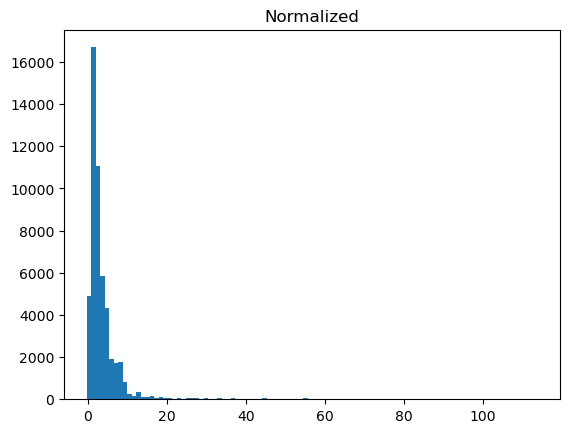

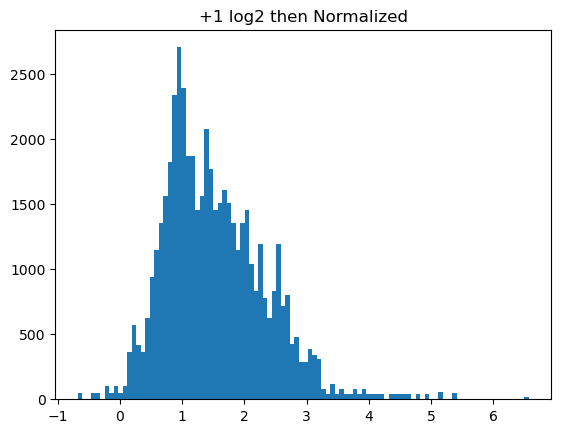

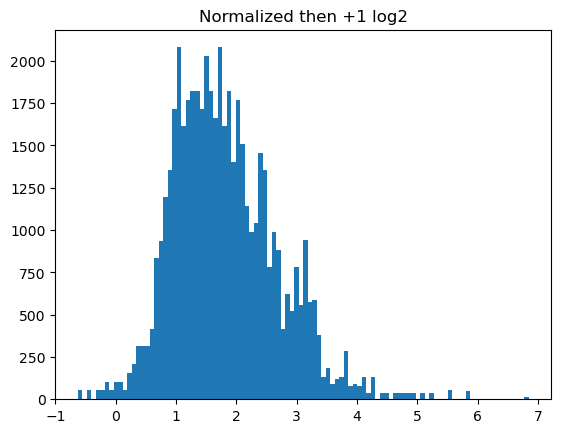

In [166]:
plt.hist(ma_data.values.flatten(), bins=100)
plt.title('Original')
plt.show()

normalized = quantile_normalize(ma_data)
plt.hist(normalized.values.flatten(), bins=100)
plt.title('Normalized')
plt.show()

normalized = quantile_normalize(np.log2(ma_data + 1))
plt.hist(normalized.values.flatten(), bins=100)
plt.title('+1 log2 then Normalized')
plt.show()

normalized = np.log2(quantile_normalize(ma_data) + 1)
plt.hist(normalized.values.flatten(), bins=100)
plt.title('Normalized then +1 log2')
plt.show()

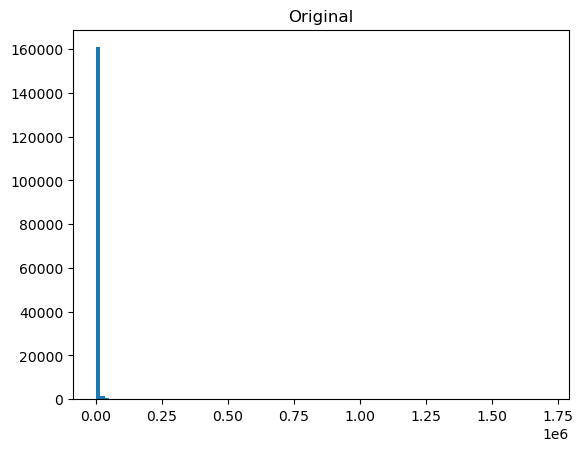

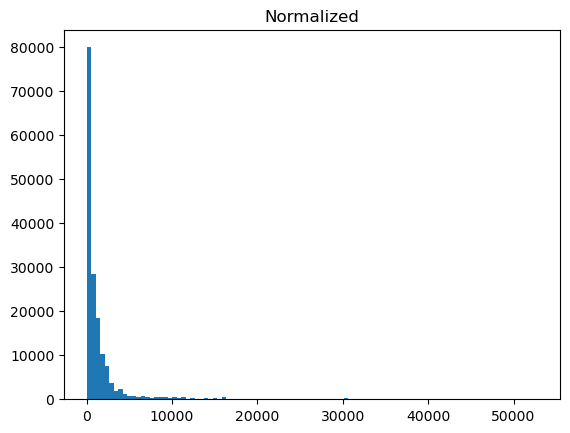

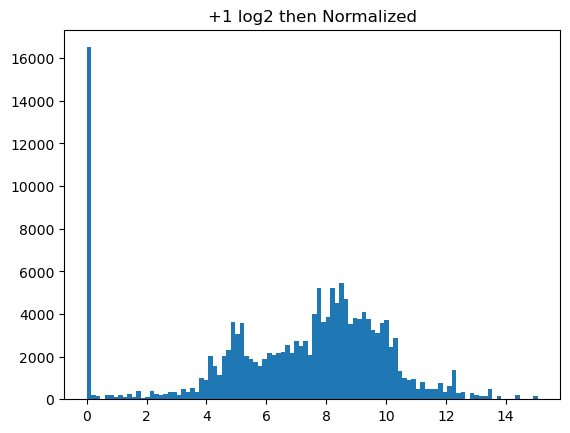

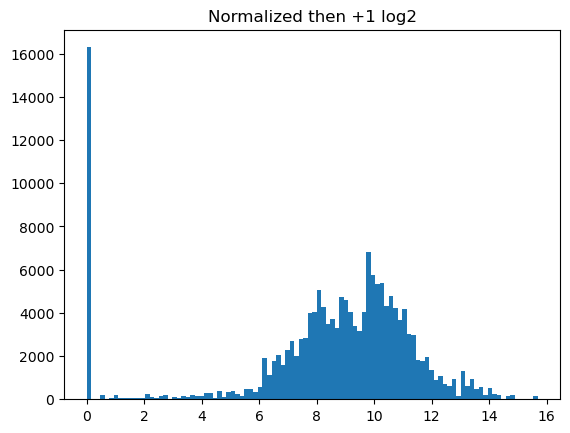

In [167]:
rna_samples = []
for disease_sample in dis_data.columns:
    if data_funcs_old.get_dis_meta(disease_sample, 'type') == 'rnaseq':
        rna_samples.append(disease_sample)
rna_data = dis_data[rna_samples]

plt.hist(rna_data.values.flatten(), bins=100)
plt.title('Original')
plt.show()

normalized = quantile_normalize(rna_data)
plt.hist(normalized.values.flatten(), bins=100)
plt.title('Normalized')
plt.show()

normalized = quantile_normalize(np.log2(rna_data + 1))
plt.hist(normalized.values.flatten(), bins=100)
plt.title('+1 log2 then Normalized')
plt.show()

normalized = np.log2(quantile_normalize(rna_data) + 1)
plt.hist(normalized.values.flatten(), bins=100)
plt.title('Normalized then +1 log2')
plt.show()